In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
file = r"C:\Users\nihal\Downloads\437\players_22.csv"
df = pd.read_csv(file, low_memory=False)
df.head(5)

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


In [3]:
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       'age',
       ...
       'lcb', 'cb', 'rcb', 'rb', 'gk', 'player_face_url', 'club_logo_url',
       'club_flag_url', 'nation_logo_url', 'nation_flag_url'],
      dtype='str', length=110)

In [4]:
df.select_dtypes(include='number')

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
0,158023,93,93,78000000.0,320000.0,34,170,72,73.0,1.0,...,96,20,35,24,6,11,15,14,8,NaN
1,188545,92,92,119500000.0,270000.0,32,185,81,21.0,1.0,...,88,35,42,19,15,6,12,8,10,NaN
2,20801,91,91,45000000.0,270000.0,36,187,83,11.0,1.0,...,95,24,32,24,7,11,15,14,11,NaN
3,190871,91,91,129000000.0,270000.0,29,175,68,73.0,1.0,...,93,35,32,29,9,9,15,15,11,NaN
4,192985,91,91,125500000.0,350000.0,30,181,70,10.0,1.0,...,89,68,65,53,15,13,5,10,13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,261962,47,52,70000.0,1000.0,22,180,64,112541.0,1.0,...,37,38,43,48,6,10,5,15,13,NaN
19235,262040,47,59,110000.0,500.0,19,175,70,445.0,1.0,...,47,37,44,47,11,12,6,8,10,NaN
19236,262760,47,55,100000.0,500.0,21,178,72,111131.0,1.0,...,36,38,44,48,8,6,7,10,6,NaN
19237,262820,47,60,110000.0,500.0,19,173,66,111131.0,1.0,...,47,10,14,11,7,10,7,14,15,NaN


In [5]:
df.shape

(19239, 110)

In [6]:
df.dtypes

sofifa_id           int64
player_url            str
short_name            str
long_name             str
player_positions      str
                    ...  
player_face_url       str
club_logo_url         str
club_flag_url         str
nation_logo_url       str
nation_flag_url       str
Length: 110, dtype: object

In [7]:
print("Null counts per column (sorted):")
print(df.isnull().sum().sort_values(ascending=False).to_string())

print(f"\nShape before cleaning: {df.shape}")

df_clean = df.dropna(subset=["wage_eur", "value_eur", "potential"]).copy()

print(f"Shape after cleaning:  {df_clean.shape}")

Null counts per column (sorted):
nation_jersey_number           18480
nation_team_id                 18480
nation_position                18480
nation_logo_url                18480
club_loaned_from               18137
player_tags                    17798
goalkeeping_speed              17107
player_traits                   9841
pace                            2132
physic                          2132
defending                       2132
dribbling                       2132
passing                         2132
shooting                        2132
release_clause_eur              1176
club_joined                     1163
value_eur                         74
league_name                       61
wage_eur                          61
league_level                      61
club_jersey_number                61
club_contract_valid_until         61
club_team_id                      61
club_logo_url                     61
club_name                         61
club_position                     61
club_

In [8]:
df_clean.describe()

,sofifa_id,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,club_team_id,league_level,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,19165.000000,19165.000000,19165.000000,1.916500e+04,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,...,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,19165.000000,2124.000000
mean,231583.648526,65.760188,71.079990,2.850452e+06,9021.721889,25.190034,181.290008,74.930342,50540.725228,1.354239,...,57.899713,46.583459,48.038664,45.897156,16.401565,16.190347,16.052961,16.225098,16.489903,36.439266
std,26833.429325,6.882803,6.087721,7.613700e+06,19476.005074,4.727515,6.862654,7.066639,54398.739305,0.747572,...,12.157264,20.201097,21.226869,20.749324,17.566193,16.834231,16.560291,17.053315,17.878079,10.750788
min,41.000000,47.000000,49.000000,9.000000e+03,500.000000,16.000000,155.000000,49.000000,1.000000,1.000000,...,12.000000,4.000000,5.000000,5.000000,2.000000,2.000000,2.000000,2.000000,2.000000,15.000000
25%,214611.000000,61.000000,67.000000,4.750000e+05,1000.000000,21.000000,176.000000,70.000000,479.000000,1.000000,...,50.000000,29.000000,28.000000,25.000000,8.000000,8.000000,8.000000,8.000000,8.000000,27.000000
50%,236586.000000,66.000000,71.000000,9.750000e+05,3000.000000,25.000000,181.000000,75.000000,1938.000000,1.000000,...,59.000000,52.000000,56.000000,53.000000,11.000000,11.000000,11.000000,11.000000,11.000000,36.000000
75%,253568.000000,70.000000,75.000000,2.000000e+06,8000.000000,29.000000,186.000000,80.000000,111139.000000,1.000000,...,66.000000,63.000000,65.000000,63.000000,14.000000,14.000000,14.000000,14.000000,14.000000,45.000000
max,264640.000000,93.000000,95.000000,1.940000e+08,350000.000000,43.000000,206.000000,110.000000,115820.000000,5.000000,...,96.000000,93.000000,93.000000,92.000000,91.000000,92.000000,93.000000,92.000000,90.000000,65.000000


**H₀: There is no linear relationship between player potential and wage (EUR).**  
**H₁: Players with higher potential tend to earn higher wages.**

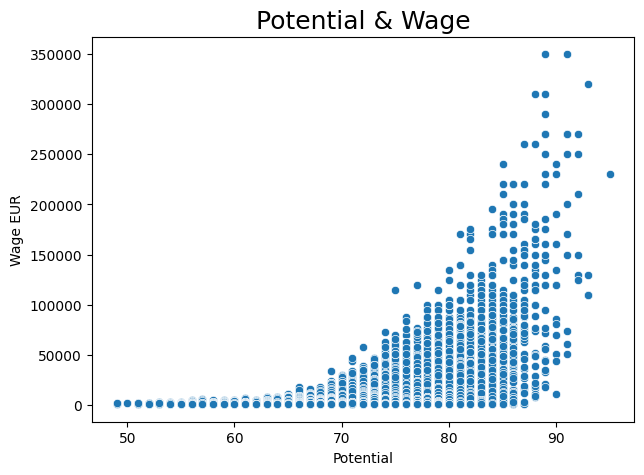

In [9]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(x=df_clean["potential"], y=df_clean["wage_eur"])
plt.xlabel("Potential")
plt.ylabel("Wage EUR")
plt.title("Potential & Wage", fontsize=18)
plt.show()

In [10]:
pair = df_clean[["potential", "wage_eur"]].dropna()
r, p = pearsonr(pair["potential"], pair["wage_eur"])
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")

rs, ps = spearmanr(pair["potential"], pair["wage_eur"])
print(f"Spearman r = {rs:.3f}, p-value = {ps:.4f}")

if p < 0.05:
    conclusion, finding = "reject H₀", "higher potential is associated with higher wages"
else:
    conclusion, finding = "fail to reject H₀", "potential shows no significant association with wages"
print(f"\nAt α = 0.05 we {conclusion}: {finding}.")

Pearson r = 0.498, p-value = 0.0000
Spearman r = 0.511, p-value = 0.0000

At α = 0.05 we reject H₀: higher potential is associated with higher wages.


**H₀: The strength of the potential–wage relationship is the same across all international reputation tiers.**  
**H₁: The strength of the potential–wage relationship varies by reputation tier.**

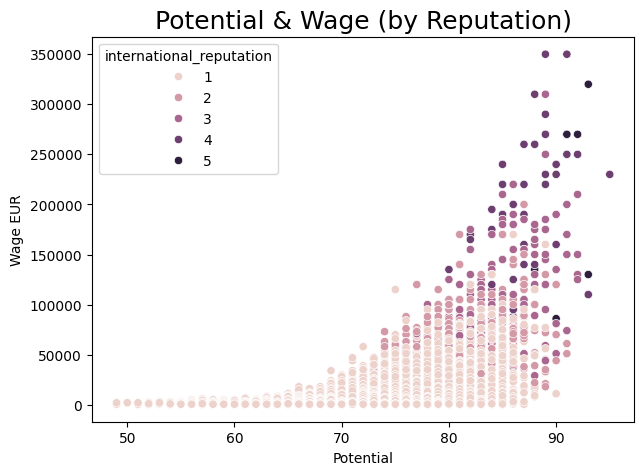

In [11]:
plt.figure(figsize=(7, 5))
ax = sns.scatterplot(x=df_clean["potential"], y=df_clean["wage_eur"],
                     hue=df_clean["international_reputation"])
plt.xlabel("Potential")
plt.ylabel("Wage EUR")
plt.title("Potential & Wage (by Reputation)", fontsize=18)
plt.show()

In [12]:
tiers = sorted(df_clean["international_reputation"].dropna().unique())
tier_r = {}
for tier in tiers:
    mask = df_clean["international_reputation"] == tier
    group = df_clean.loc[mask, ["potential", "wage_eur"]].dropna()
    r, p = pearsonr(group["potential"], group["wage_eur"])
    tier_r[int(tier)] = r
    flag = "  <-- NOT significant (p > 0.05; sample too small)" if p > 0.05 else ""
    print(f"Reputation tier {int(tier)}: Pearson r = {r:.3f}, p-value = {p:.4f} (n={len(group)}){flag}")

spread = max(tier_r.values()) - min(tier_r.values())
print(f"\nThe correlation ranges from r = {min(tier_r.values()):.3f} to r = {max(tier_r.values()):.3f} "
      f"across tiers (spread = {spread:.3f}).")
print("We reject H₀: the strength of the potential–wage relationship varies by reputation tier,")
print("strengthening as international reputation rises.")

Reputation tier 1: Pearson r = 0.451, p-value = 0.0000 (n=17786)
Reputation tier 2: Pearson r = 0.612, p-value = 0.0000 (n=1033)
Reputation tier 3: Pearson r = 0.688, p-value = 0.0000 (n=281)


Reputation tier 4: Pearson r = 0.709, p-value = 0.0000 (n=57)
Reputation tier 5: Pearson r = 0.684, p-value = 0.0614 (n=8)  <-- NOT significant (p > 0.05; sample too small)

The correlation ranges from r = 0.451 to r = 0.709 across tiers (spread = 0.258).
We reject H₀: the strength of the potential–wage relationship varies by reputation tier,
strengthening as international reputation rises.


**H₀: There is no linear relationship between player potential and market value (EUR).**  
**H₁: Players with higher potential command higher market values.**

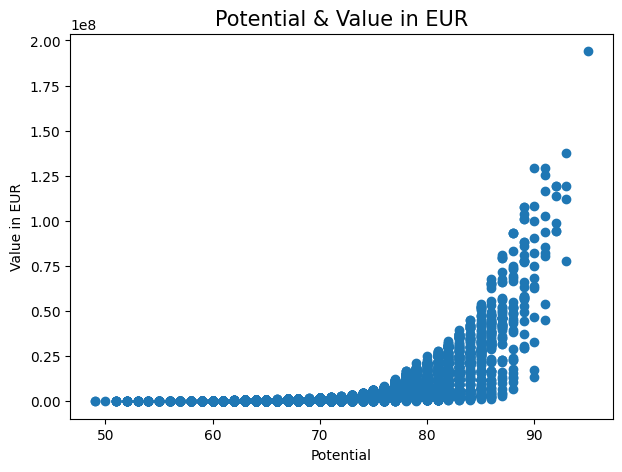

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["potential"], df_clean["value_eur"])
ax.set_xlabel("Potential")
ax.set_ylabel("Value in EUR")
ax.set_title("Potential & Value in EUR", fontsize=15)
plt.show()

In [14]:
pair = df_clean[["potential", "value_eur"]].dropna()
r, p = pearsonr(pair["potential"], pair["value_eur"])
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")

rs, ps = spearmanr(pair["potential"], pair["value_eur"])
print(f"Spearman r = {rs:.3f}, p-value = {ps:.4f}")

if p < 0.05:
    conclusion, finding = "reject H₀", "higher potential is associated with higher market value"
else:
    conclusion, finding = "fail to reject H₀", "potential shows no significant association with market value"
print(f"\nAt α = 0.05 we {conclusion}: {finding}.")

Pearson r = 0.528, p-value = 0.0000


Spearman r = 0.808, p-value = 0.0000



At α = 0.05 we reject H₀: higher potential is associated with higher market value.


**H₀: International reputation has no monotonic relationship with market value (EUR).**  
**H₁: Higher international reputation is associated with higher market value.**

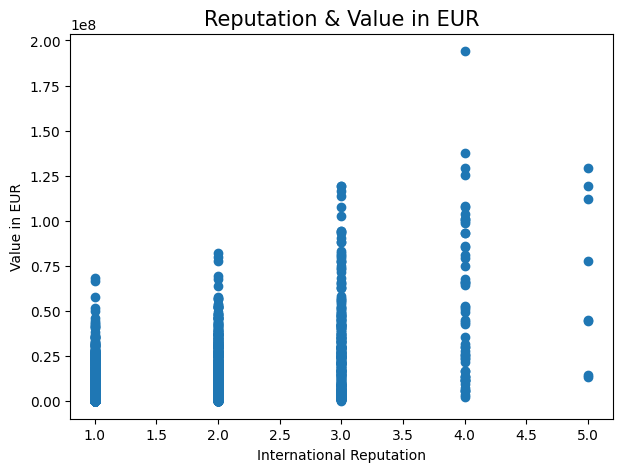

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["international_reputation"], df_clean["value_eur"])
ax.set_xlabel("International Reputation")
ax.set_ylabel("Value in EUR")
ax.set_title("Reputation & Value in EUR", fontsize=15)
plt.show()

In [16]:
pair = df_clean[["international_reputation", "value_eur"]].dropna()
r, p = spearmanr(pair["international_reputation"], pair["value_eur"])
print(f"Spearman r = {r:.3f}, p-value = {p:.4f}")

if p < 0.05:
    conclusion, finding = "reject H₀", "higher international reputation is associated with higher market value"
else:
    conclusion, finding = "fail to reject H₀", "international reputation shows no significant monotonic association with market value"
print(f"\nAt α = 0.05 we {conclusion}: {finding}.")

Spearman r = 0.343, p-value = 0.0000

At α = 0.05 we reject H₀: higher international reputation is associated with higher market value.


**H₀: International reputation has no monotonic relationship with wages (EUR).**  
**H₁: Players with higher international reputation earn higher wages.**

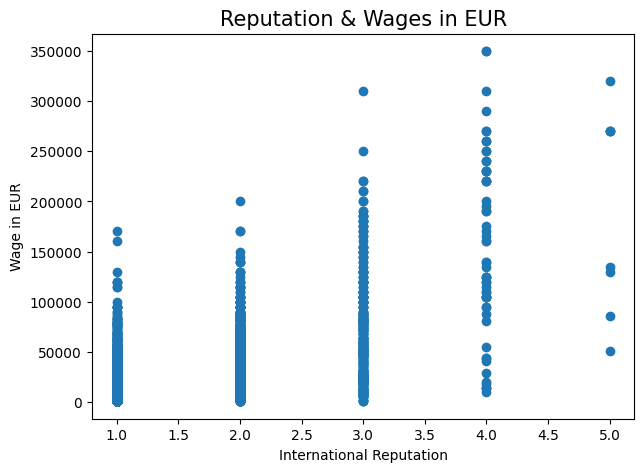

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["international_reputation"], df_clean["wage_eur"])
ax.set_xlabel("International Reputation")
ax.set_ylabel("Wage in EUR")
ax.set_title("Reputation & Wages in EUR", fontsize=15)
plt.show()

In [18]:
pair = df_clean[["international_reputation", "wage_eur"]].dropna()
r, p = spearmanr(pair["international_reputation"], pair["wage_eur"])
print(f"Spearman r = {r:.3f}, p-value = {p:.4f}")

if p < 0.05:
    conclusion, finding = "reject H₀", "higher international reputation is associated with higher wages"
else:
    conclusion, finding = "fail to reject H₀", "international reputation shows no significant monotonic association with wages"
print(f"\nAt α = 0.05 we {conclusion}: {finding}.")

Spearman r = 0.377, p-value = 0.0000

At α = 0.05 we reject H₀: higher international reputation is associated with higher wages.


**H₀: There is no linear relationship between a player’s height and their potential rating.**  
**H₁: Taller players tend to have higher potential ratings.**

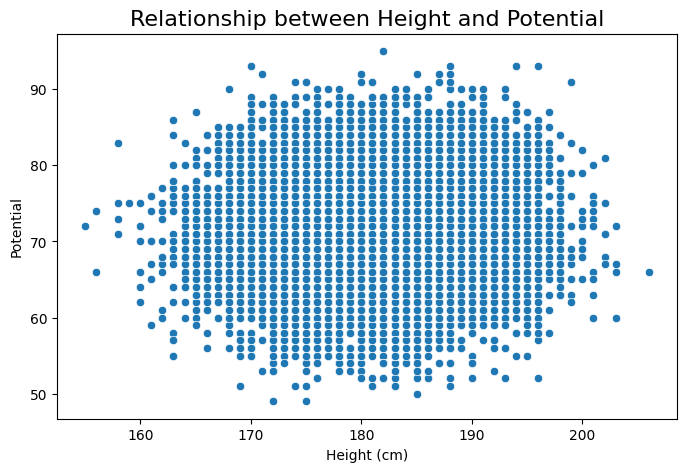

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=df_clean["height_cm"], y=df_clean["potential"], ax=ax)
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Potential")
ax.set_title("Relationship between Height and Potential", fontsize=16)
plt.show()

In [20]:
pair = df_clean[["height_cm", "potential"]].dropna()
r, p = pearsonr(pair["height_cm"], pair["potential"])
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")

if p < 0.05:
    conclusion, finding = "reject H₀", "height and potential are significantly linearly related"
else:
    conclusion, finding = "fail to reject H₀", "there is no detectable linear relationship between height and potential"
print(f"\nAt α = 0.05 we {conclusion}: {finding}.")

Pearson r = 0.004, p-value = 0.5709

At α = 0.05 we fail to reject H₀: there is no detectable linear relationship between height and potential.


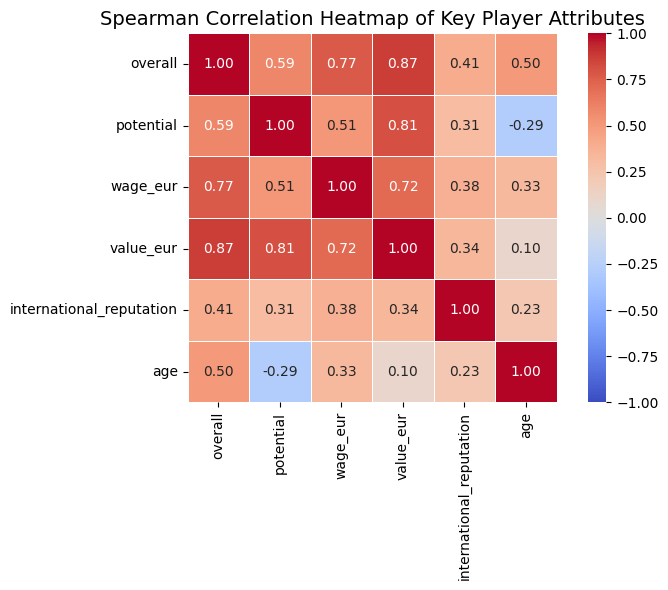

In [21]:
heatmap_cols = ["overall", "potential", "wage_eur", "value_eur",
               "international_reputation", "age"]

corr_matrix = df_clean[heatmap_cols].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Spearman Correlation Heatmap of Key Player Attributes", fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
top_15 = df_clean.nlargest(15, 'overall')
top_15

,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png
5,200389,https://sofifa.com/player/200389/jan-oblak/220002,J. Oblak,Jan Oblak,GK,91,93,112000000.0,130000.0,28,...,33+3,33+3,33+3,32+3,89+3,https://cdn.sofifa.net/players/200/389/22_120.png,https://cdn.sofifa.net/teams/240/60.png,https://cdn.sofifa.net/flags/es.png,NaN,https://cdn.sofifa.net/flags/si.png
6,231747,https://sofifa.com/player/231747/kylian-mbappe...,K. Mbappé,Kylian Mbappé Lottin,"ST, LW",91,95,194000000.0,230000.0,22,...,54+3,54+3,54+3,63+3,18+3,https://cdn.sofifa.net/players/231/747/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1335/60.png,https://cdn.sofifa.net/flags/fr.png
7,167495,https://sofifa.com/player/167495/manuel-neuer/...,M. Neuer,Manuel Peter Neuer,GK,90,90,13500000.0,86000.0,35,...,34+3,34+3,34+3,35+3,88+2,https://cdn.sofifa.net/players/167/495/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1337/60.png,https://cdn.sofifa.net/flags/de.png
8,192448,https://sofifa.com/player/192448/marc-andre-te...,M. ter Stegen,Marc-André ter Stegen,GK,90,92,99000000.0,250000.0,29,...,33+3,33+3,33+3,31+3,88+3,https://cdn.sofifa.net/players/192/448/22_120.png,https://cdn.sofifa.net/teams/241/60.png,https://cdn.sofifa.net/flags/es.png,NaN,https://cdn.sofifa.net/flags/de.png
9,202126,https://sofifa.com/player/202126/harry-kane/22...,H. Kane,Harry Kane,ST,90,90,129500000.0,240000.0,27,...,61+3,61+3,61+3,64+3,20+3,https://cdn.sofifa.net/players/202/126/22_120.png,https://cdn.sofifa.net/teams/18/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1318/60.png,https://cdn.sofifa.net/flags/gb-eng.png


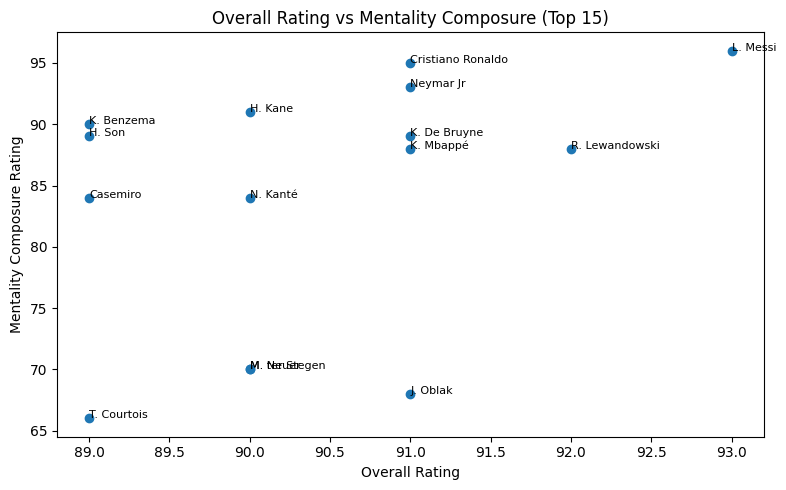

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(top_15["overall"], top_15["mentality_composure"])

for i in range(len(top_15)):
    ax.text(top_15.iloc[i]["overall"],
            top_15.iloc[i]["mentality_composure"],
            top_15.iloc[i]["short_name"], fontsize=8)

ax.set_title("Overall Rating vs Mentality Composure (Top 15)")
ax.set_ylabel("Mentality Composure Rating")
ax.set_xlabel("Overall Rating")
plt.tight_layout()
plt.show()

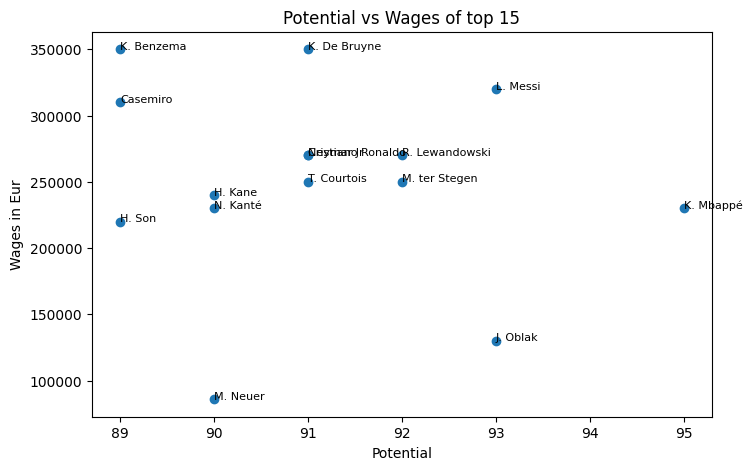

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(top_15['potential'], top_15['wage_eur'])
for _, row in top_15.iterrows():
    ax.text(row['potential'], row['wage_eur'], row['short_name'], fontsize=8)

ax.set_title("Potential vs Wages of top 15")
ax.set_ylabel('Wages in Eur')
ax.set_xlabel('Potential')

plt.show()

In [25]:
df_clean.groupby("work_rate")["wage_eur"].mean().round(2)

work_rate
High/High        17467.31
High/Low          9953.97
High/Medium      11695.62
Low/High          9645.47
Low/Low           9265.12
Low/Medium        7285.17
Medium/High      11046.73
Medium/Low        8771.44
Medium/Medium     6738.91
Name: wage_eur, dtype: float64

In [26]:
df_clean['work_rate'].unique()

<StringArray>
[   'Medium/Low',   'High/Medium',      'High/Low',     'High/High',
 'Medium/Medium',   'Medium/High',      'Low/High',    'Low/Medium',
       'Low/Low']
Length: 9, dtype: str

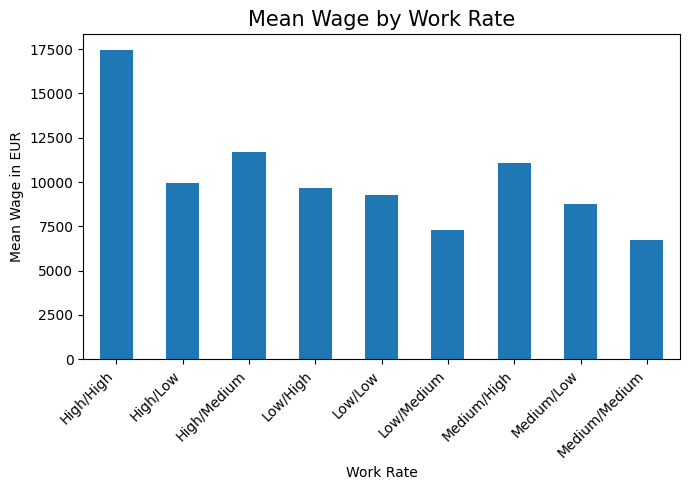

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
df_clean.groupby("work_rate")["wage_eur"].mean().plot.bar(ax=ax)
ax.set_xlabel("Work Rate")
ax.set_ylabel("Mean Wage in EUR")
ax.set_title("Mean Wage by Work Rate", fontsize=15)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

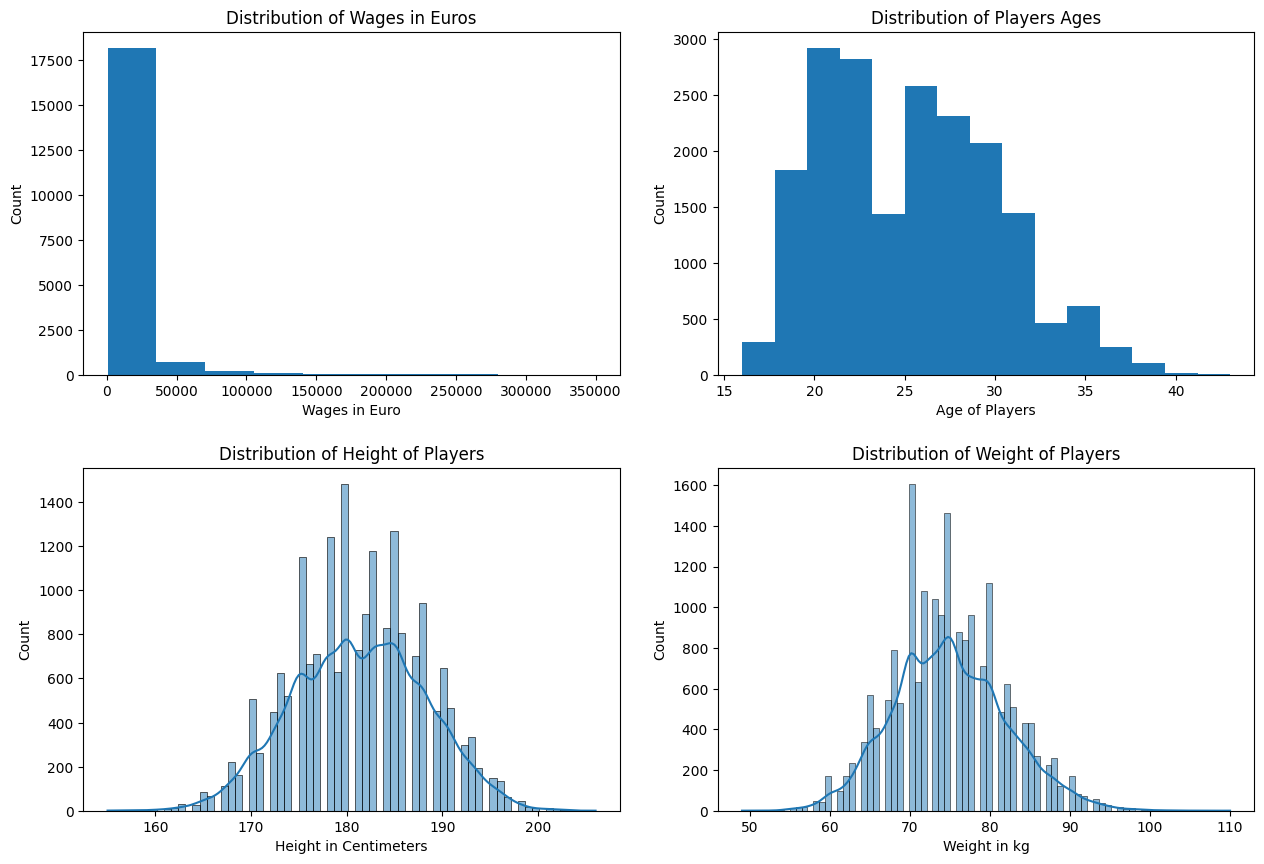

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].hist(df_clean['wage_eur'])
axes[0,0].set_xlabel('Wages in Euro')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of Wages in Euros')

axes[0,1].hist(df_clean['age'], bins = 15)
axes[0,1].set_xlabel('Age of Players')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Players Ages')

axes[1,0].set_title('Distribution of Height of Players')
sns.histplot(df_clean, x='height_cm', ax=axes[1,0], kde=True)
axes[1,0].set_xlabel('Height in Centimeters')
axes[1,0].set_ylabel('Count')

axes[1,1].set_title('Distribution of Weight of Players')
sns.histplot(df_clean, x='weight_kg', ax=axes[1,1], kde=True)
axes[1,1].set_xlabel('Weight in kg')
axes[1,1].set_ylabel('Count')

plt.tight_layout(pad=2)
plt.show()

In [29]:
df_clean.groupby(['preferred_foot']).count()[['sofifa_id']]

,sofifa_id
preferred_foot,
Left,4549
Right,14616


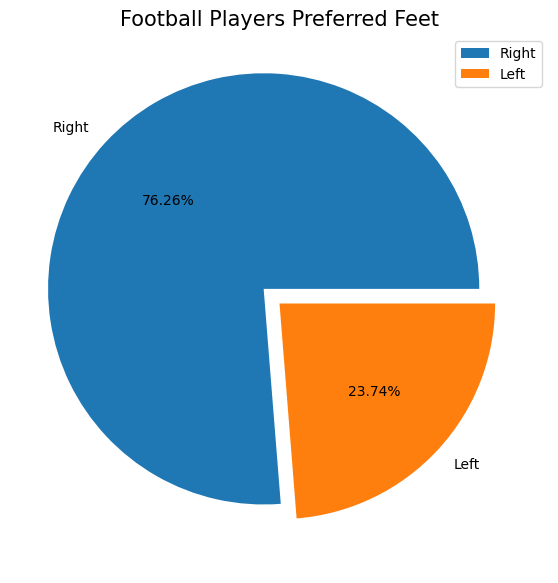

In [30]:
preferred_foot_labels = df_clean["preferred_foot"].value_counts().index
preferred_foot_values = df_clean["preferred_foot"].value_counts().values
explode = [0.1 if i == 0 else 0 for i in range(len(preferred_foot_values))]

plt.figure(figsize=(7, 7))
plt.pie(preferred_foot_values, labels=preferred_foot_labels,
        autopct="%1.2f%%", explode=explode)
plt.title("Football Players Preferred Feet", color="black", fontsize=15)
plt.legend()
plt.show()

In [31]:
df_clean['nationality_name'].value_counts()

nationality_name
England      1717
Germany      1214
Spain        1085
France        980
Argentina     956
             ... 
Bhutan          1
Barbados        1
Gibraltar       1
Estonia         1
Indonesia       1
Name: count, Length: 163, dtype: int64

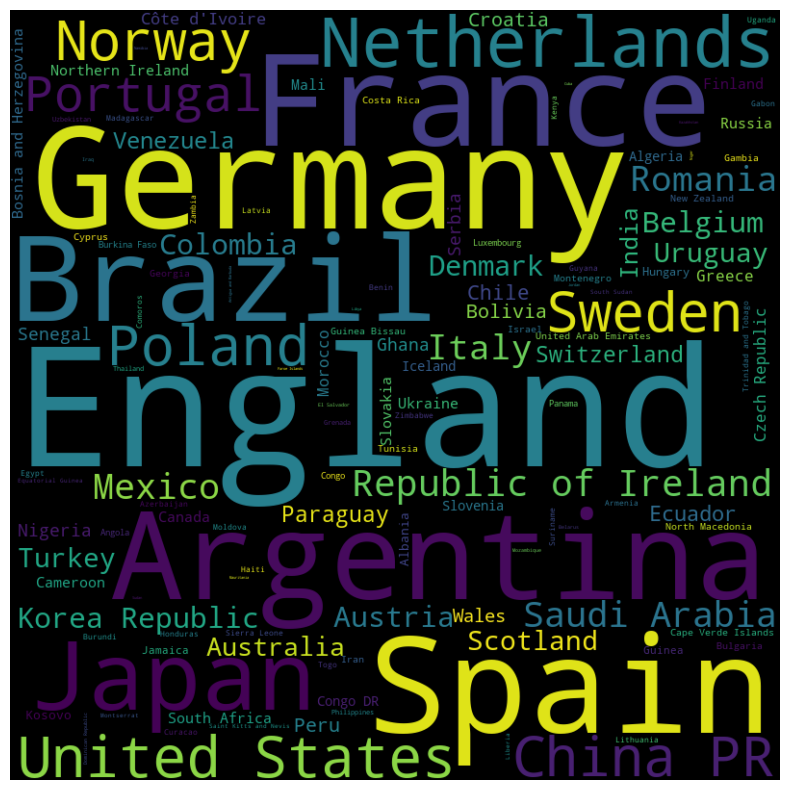

In [32]:
nationality_freq = df_clean['nationality_name'].value_counts().to_dict()
plt.figure(figsize=(10, 10))
wc = WordCloud(width=800, height=800).generate_from_frequencies(nationality_freq)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [33]:
bar_plot = dict(Counter(df_clean['nationality_name'].values).most_common(5))
bar_plot

{'England': 1717,
 'Germany': 1214,
 'Spain': 1085,
 'France': 980,
 'Argentina': 956}

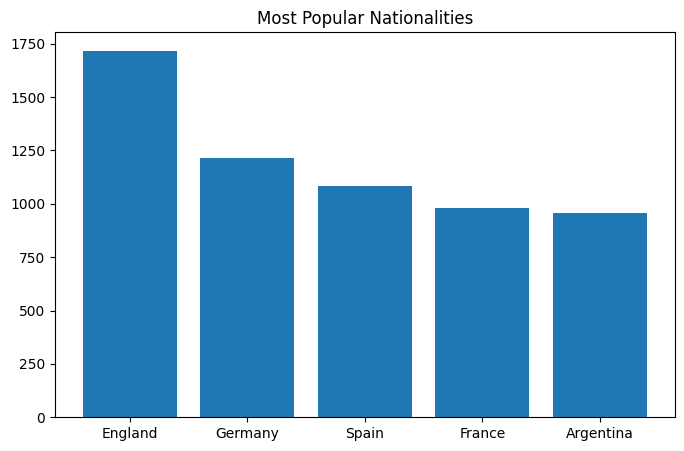

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(*zip(*bar_plot.items()))
ax.set_title('Most Popular Nationalities')
plt.show()

In [35]:
def plot_most_common(category, data=None, ax=None):
    if data is None:
        data = df_clean
    own_axes = ax is None
    if own_axes:
        fig, ax = plt.subplots(figsize=(8, 5))
    bar_plot = dict(Counter(data[category].values).most_common(5))
    ax.bar(*zip(*bar_plot.items()))
    ax.set_title(f"5 Most Common Values - {category}")
    ax.set_xlabel(category)
    ax.set_ylabel("Count")
    if own_axes:
        plt.show()

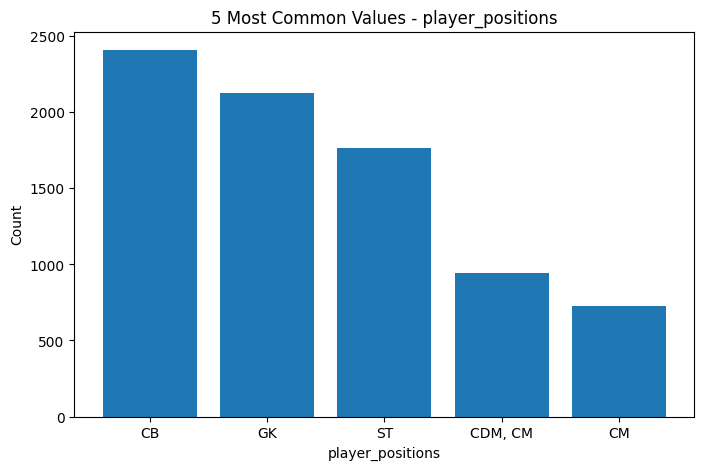

In [36]:
plot_most_common('player_positions')

In [37]:
player_name = df_clean[['wage_eur','short_name',
                  'value_eur','overall','age',
                  'nationality_name','potential',
                  'international_reputation']].nlargest(10,['wage_eur']).set_index('short_name')
player_name

,wage_eur,value_eur,overall,age,nationality_name,potential,international_reputation
short_name,,,,,,,
K. De Bruyne,350000.0,125500000.0,91,30,Belgium,91,4
K. Benzema,350000.0,66000000.0,89,33,France,89,4
L. Messi,320000.0,78000000.0,93,34,Argentina,93,5
Casemiro,310000.0,88000000.0,89,29,Brazil,89,3
T. Kroos,310000.0,75000000.0,88,31,Germany,88,4
R. Sterling,290000.0,107500000.0,88,26,England,89,4
R. Lewandowski,270000.0,119500000.0,92,32,Poland,92,5
Cristiano Ronaldo,270000.0,45000000.0,91,36,Portugal,91,5
Neymar Jr,270000.0,129000000.0,91,29,Brazil,91,5


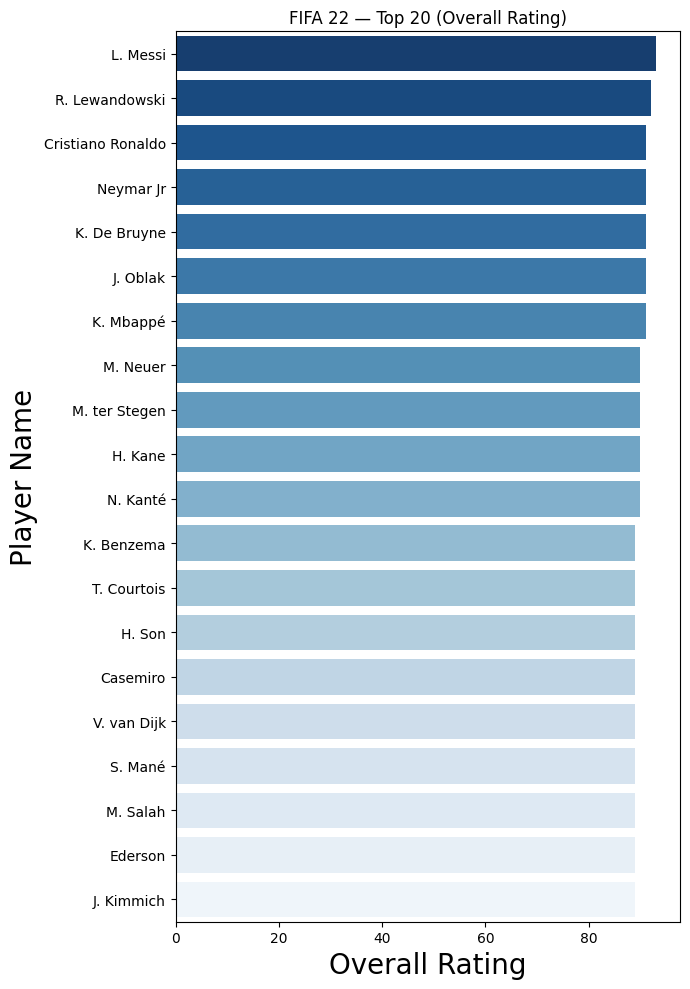

In [38]:
top_20 = df_clean.nlargest(20, "overall")[["short_name", "overall"]]

plt.figure(figsize=(7, 10))
ax = sns.barplot(x=top_20["overall"], y=top_20["short_name"],
                 hue=top_20["short_name"], palette="Blues_r",
                 orient="h", legend=False)
plt.xlabel("Overall Rating", size=20)
plt.ylabel("Player Name", size=20)
plt.title("FIFA 22 — Top 20 (Overall Rating)")
plt.tight_layout()
plt.show()

In [39]:
features = ["potential", "international_reputation", "overall"]
target   = "wage_eur"

model_df = df_clean[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.2f} EUR")

R²   = 0.5873
RMSE = 12530.03 EUR


In [40]:
def variance_inflation_factors(X):
    vifs = {}
    for col in X.columns:
        others = [c for c in X.columns if c != col]
        r2_j = LinearRegression().fit(X[others], X[col]).score(X[others], X[col])
        vifs[col] = 1.0 / (1.0 - r2_j)
    return vifs

for feat, v in variance_inflation_factors(X_train).items():
    flag = "  <-- high collinearity (consider dropping)" if v > 5 else ""
    print(f"VIF[{feat}] = {v:.2f}{flag}")

VIF[potential] = 1.73
VIF[international_reputation] = 1.30
VIF[overall] = 1.94


In [41]:
y_train_log = np.log1p(y_train)

model_log = LinearRegression()
model_log.fit(X_train, y_train_log)

y_pred_log = np.expm1(model_log.predict(X_test))
r2_log   = r2_score(y_test, y_pred_log)
rmse_log = mean_squared_error(y_test, y_pred_log) ** 0.5

print("Baseline (untransformed target):")
print(f"  R2 = {r2:.4f}   RMSE = {rmse:,.2f} EUR")
print("Log-transformed target (predictions back-transformed to EUR):")
print(f"  R2 = {r2_log:.4f}   RMSE = {rmse_log:,.2f} EUR")
print()
verdict = "improves" if r2_log > r2 else "does not improve"
print(f"On this feature set, log-transforming the target {verdict} test R-squared.")

Baseline (untransformed target):
  R2 = 0.5873   RMSE = 12,530.03 EUR
Log-transformed target (predictions back-transformed to EUR):
  R2 = 0.4533   RMSE = 14,421.60 EUR

On this feature set, log-transforming the target does not improve test R-squared.


In [42]:
train_means = X_train.mean()

def engineer(frame):
    oc = frame["overall"] - train_means["overall"]
    pc = frame["potential"] - train_means["potential"]
    rc = frame["international_reputation"] - train_means["international_reputation"]
    return frame.assign(
        overall_sq=oc ** 2,
        potential_sq=pc ** 2,
        rep_x_overall=rc * oc,
    )

X_train_enh = engineer(X_train)
X_test_enh = engineer(X_test)

model_enh = LinearRegression().fit(X_train_enh, y_train)
y_pred_enh = model_enh.predict(X_test_enh)
r2_enh = r2_score(y_test, y_pred_enh)
rmse_enh = mean_squared_error(y_test, y_pred_enh) ** 0.5

print("Enhanced linear model -- VIF on centered polynomial / interaction features:")
for feat, v in variance_inflation_factors(X_train_enh).items():
    flag = "  <-- high collinearity" if v > 5 else ""
    print(f"  VIF[{feat}] = {v:.2f}{flag}")

print()
print(f"Baseline linear:  R2 = {r2:.4f}   RMSE = {rmse:,.2f} EUR")
print(f"Enhanced linear:  R2 = {r2_enh:.4f}   RMSE = {rmse_enh:,.2f} EUR")
verdict = "improves" if r2_enh > r2 else "does not improve"
print(f"Polynomial + centered interaction terms {verdict} test R-squared.")

Enhanced linear model -- VIF on centered polynomial / interaction features:
  VIF[potential] = 1.81
  VIF[international_reputation] = 8.28  <-- high collinearity
  VIF[overall] = 2.23
  VIF[overall_sq] = 2.12
  VIF[potential_sq] = 1.49
  VIF[rep_x_overall] = 8.57  <-- high collinearity

Baseline linear:  R2 = 0.5873   RMSE = 12,530.03 EUR
Enhanced linear:  R2 = 0.7650   RMSE = 9,453.98 EUR
Polynomial + centered interaction terms improves test R-squared.


In [43]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("Model comparison (test set, target wage_eur in EUR):")
print(f"  Baseline linear     R2 = {r2:.4f}   RMSE = {rmse:>12,.2f}")
print(f"  Log-target linear   R2 = {r2_log:.4f}   RMSE = {rmse_log:>12,.2f}")
print(f"  Enhanced linear     R2 = {r2_enh:.4f}   RMSE = {rmse_enh:>12,.2f}")
print(f"  Random forest       R2 = {r2_rf:.4f}   RMSE = {rmse_rf:>12,.2f}")

print("\nRandom forest feature importances:")
importances = sorted(zip(features, rf_model.feature_importances_),
                     key=lambda kv: kv[1], reverse=True)
for feat, imp in importances:
    print(f"  {feat:<26} {imp:.4f}")

Model comparison (test set, target wage_eur in EUR):
  Baseline linear     R2 = 0.5873   RMSE =    12,530.03
  Log-target linear   R2 = 0.4533   RMSE =    14,421.60
  Enhanced linear     R2 = 0.7650   RMSE =     9,453.98
  Random forest       R2 = 0.7202   RMSE =    10,316.88

Random forest feature importances:
  overall                    0.9149
  potential                  0.0543
  international_reputation   0.0308


## Conclusion

**Hypothesis tests (α = 0.05)**

| # | Test | Result | Decision |
|---|------|--------|----------|
| 1 | Potential vs. wage | Pearson r ≈ 0.50, p < 0.001 | Reject H₀ — higher potential, higher wage |
| 2 | Potential–wage strength across reputation tiers | r rises 0.45 → 0.71 across tiers | Reject H₀ — the relationship strengthens with reputation |
| 3 | Potential vs. market value | Pearson r ≈ 0.53, Spearman r ≈ 0.81, p < 0.001 | Reject H₀ — higher potential, higher value |
| 4 | Reputation vs. market value | Spearman r ≈ 0.34, p < 0.001 | Reject H₀ — higher reputation, higher value |
| 5 | Reputation vs. wage | Spearman r ≈ 0.38, p < 0.001 | Reject H₀ — higher reputation, higher wage |
| 6 | Height vs. potential | Pearson r ≈ 0.00, p ≈ 0.57 | Fail to reject H₀ — no linear relationship |

Five of six relationships are statistically significant; height is the lone non-predictor of potential.

**Predictive modelling (target: `wage_eur`)**

| Model | Test R² | Test RMSE (EUR) |
|-------|---------|-----------------|
| Baseline linear | 0.59 | ≈ 12,530 |
| Log-target linear | 0.45 | ≈ 14,422 |
| Enhanced linear (polynomial + interaction) | **0.77** | **≈ 9,454** |
| Random forest | 0.72 | ≈ 10,317 |

The **enhanced linear model** performed best: centred polynomial and reputation×overall interaction terms capture the non-linear, accelerating growth of wages at the top of the rating scale that the baseline linear model misses. The random forest came a close second and confirms which inputs matter most — its feature importances are dominated by `overall`, consistent with overall rating being the strongest single driver of wage. Log-transforming the target hurt performance here. Across both the hypothesis tests and the models, **overall rating, potential, and international reputation are the consistent drivers of wage and value**, while physical attributes such as height are not.